# MCQMC 2026 Plenary Talk Running Example

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vf}{\boldsymbol{f}}
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vu}{\boldsymbol{u}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vy}{\boldsymbol{y}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vmu}{\boldsymbol{\mu}}
\newcommand{\mSigma}{\mathsf{\Sigma}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\Norm}{\operatorname{Norm}}
\newcommand{\GP}{\operatorname{GP}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

We observe noisy function values

$$
Y_i = f(x_i) + \epsilon_i, \qquad 
\epsilon_i \sim \Norm(0,\sigma^2),
\qquad i=1,\ldots,m,
$$

and place a Gaussian process prior on the unknown function,

$$
f \sim \GP(0,K_\theta).
$$

Because the prior and likelihood are Gaussian, the posterior distribution of the vector of latent function values on a grid,

$$
\vf =
\bigl(f(t_1),\ldots,f(t_d)\bigr)^\top,
$$

obeys a multivariate normal,

$$
\vf \mid \vy
\sim
\Norm(\vmu,\mSigma).
$$

The quantity of interest is the posterior probability that the latent function remains below a safety threshold $c$ on the grid:

$$
p
=
\Pr\{ f(t_j) \le c,\ j=1,\ldots,d \mid \vy \}
=
\int_{\mathbb{R}^d}
\mathbb{1}\{\vz \le c\mathbf{1}\}
\,
\phi_d(\vz;\vmu,\mSigma)
\,\dif \vz.
$$

After a transformation from independent uniforms to the posterior Gaussian vector, this becomes an integral over the unit cube,

$$
p
=
\int_{[0,1]^d}
g(\vu)\,\dif \vu.
$$

This single example lets us compare Monte Carlo and quasi-Monte Carlo sampling, study the effect of variable transformations, test randomized error estimation, and later consider refinements such as multilevel or dimension-reduction strategies.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.stats as stats
import qmcpy as qp
import time
import pandas as pd
from IPython.display import display, Markdown

import classlib as cl
import classlib.nbviz as nb

from qmcpy.util import MaxSamplesWarning
import warnings

%matplotlib inline

rng_seed = 20260527
rng = np.random.default_rng(rng_seed)

nb.init(use_tex=True)
colors = nb.TOL_BRIGHT
nb.configure(
    figpath="MCQMC26_figures",
    savefigs=True,
    imgfrmt="png",
)

nb.SAVEFIGS = False;

## Notebook parameters

In [22]:
rng_seed = 20260527

n_obs = 9 #number of observations of the function, i.e., where the data is taken
d_grid = 64 #number of evaluation points along the line, i.e., where I need the function to be under the threshold

sigma_noise = 0.15 #standard deviation of noise in the observations
jitter = 1e-10 #to avoid ill-conditioning

threshold = 0.20        # threshold acts pointwise: penalize g(t) > threshold
risk_threshold = 0.01   # risk_threshold acts globally: penalize J(g) > risk_threshold
smooth_tau = 0.002      # smoothing scale for soft outer penalty


# Synthetic data and Gaussian process posterior

In [23]:
rng = np.random.default_rng(rng_seed)

def f_true(x):
    return (
        -0.2
        + 0.1 * np.cos(2 * np.pi*x)
        + 0.35 * np.sin(2 * np.pi * x)
        + 0.22 * np.cos(6 * np.pi * x)
        + 0.12 * np.sin(10 * np.pi * x)
    )

def sqexp_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    return amp**2 * np.exp(-0.5 * ((x - z) / ell)**2)

def matern52_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt5r = np.sqrt(5) * r
    return amp**2 * (1 + sqrt5r + 5 * r**2 / 3) * np.exp(-sqrt5r)

def matern32_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt3r = np.sqrt(3) * r
    return amp**2 * (1 + sqrt3r) * np.exp(-sqrt3r)

kernel = matern32_kernel

x_obs = np.linspace(0.08, 0.92, n_obs)
y_obs = f_true(x_obs) + sigma_noise * rng.standard_normal(n_obs)

t_grid = np.linspace(0, 1, d_grid)

K_xx = kernel(x_obs, x_obs)
K_tx = kernel(t_grid, x_obs)
K_tt = kernel(t_grid, t_grid)

A = K_xx + sigma_noise**2 * np.eye(n_obs)
L_A = np.linalg.cholesky(A + jitter * np.eye(n_obs))

alpha = np.linalg.solve(L_A.T, np.linalg.solve(L_A, y_obs))
post_mean = K_tx @ alpha

V = np.linalg.solve(L_A, K_tx.T)
post_cov = K_tt - V.T @ V
post_cov = 0.5 * (post_cov + post_cov.T)

L_post = np.linalg.cholesky(post_cov + jitter * np.eye(d_grid))

# Plot posterior mean and pointwise credible band

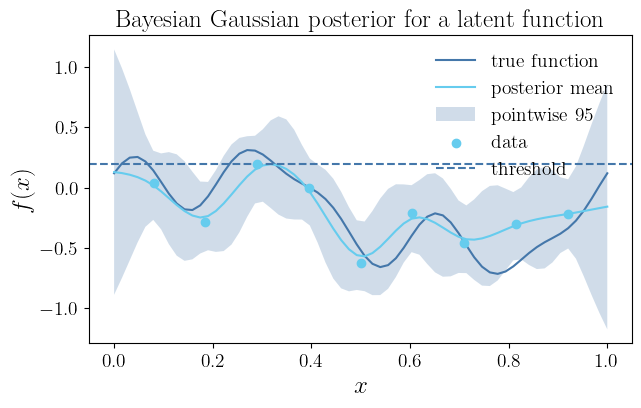

In [24]:
post_sd = np.sqrt(np.diag(post_cov))

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(t_grid, f_true(t_grid), label="true function")
ax.plot(t_grid, post_mean, label="posterior mean")
ax.fill_between(
    t_grid,
    post_mean - 1.96 * post_sd,
    post_mean + 1.96 * post_sd,
    alpha=0.25,
    label="pointwise 95% band",
)
ax.scatter(x_obs, y_obs, zorder=5, label="data")
ax.axhline(threshold, linestyle="--", label="threshold")

ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Bayesian Gaussian posterior for a latent function")
ax.legend(loc="best")

if nb.SAVEFIGS:
    nb.savefig("posterior_gp_example")
plt.show()

# Quantity of interest: posterior probability that the curve stays below the threshold

## Beginning of the transforms dictionary of integrands

In [25]:
def local_loss(g):
    return np.maximum(g - threshold, 0.0)**2

def spatial_risk(f_samples):
    return np.trapezoid(local_loss(f_samples), x=t_grid, axis=-1)

def outer_penalty(J, a=risk_threshold, tau=None):
    if tau is None:
        return (J > a).astype(float)
    return 1 / (1 + np.exp(-(J - a) / tau))

def direct_integrand(u, *, smooth=False):
    u = np.asarray(u)
    u = np.clip(u, np.finfo(float).eps, 1 - np.finfo(float).eps)

    z = stats.norm.ppf(u)

    f_samples = post_mean + z @ L_post.T

    J = spatial_risk(f_samples)

    if smooth:
        return outer_penalty(J, a=risk_threshold, tau=smooth_tau)
    return outer_penalty(J, a=risk_threshold)

transforms = {
    "direct": {
        "label": "Direct risk transform",
        "short_label": "Direct",
        "integrand": direct_integrand,
        "savefig_suffix": "direct",
    },
}

transform_key = "direct"
transform = transforms[transform_key]

## First direct integrand Monte Carlo and Sobol' checks

In [26]:
def check_transform_estimates(transform_key, n=2**12, d_grid=d_grid):
    transform = transforms[transform_key]
    integrand = transform["integrand"]

    # IID MC check
    vals = np.asarray(integrand(qp.IIDStdUniform(d_grid)(n))).reshape(-1)
    mc_sol = vals.mean()
    mc_err = 1.96 * vals.std(ddof=1) / math.sqrt(vals.size)
    
    # Sobol' fixed-budget CubQMCNetG check
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", MaxSamplesWarning)

        sobol_g_sol, sobol_g_data = qp.CubQMCNetG(
            qp.CustomFun(
                qp.Uniform(qp.Sobol(d_grid)),
                integrand,
            ),
            abs_tol=1e-12,
            n_init=n,
            n_limit=n,
        ).integrate()

        clt_rep=2**4
        sobol_clt_sol, sobol_clt_data = qp.CubQMCRepStudentT(
            qp.CustomFun(
                qp.Uniform(qp.Sobol(d_grid,replications=clt_rep)),
                integrand,
            ),
            abs_tol=1e-12,
            n_init=n//clt_rep,
            n_limit=n,
        ).integrate()

    sobol_g_err = sobol_g_data.comb_bound_diff / 2
    sobol_clt_err = sobol_clt_data.comb_bound_diff / 2

    message = (
        f"For the {transform['label']}\n"
        f"Based on n = {n} samples and d = {d_grid} discretization\n"
        f"IID MC:  {mc_sol:.5f} +/- {mc_err:.5f}\n"
        f"Sobol' G:  {sobol_g_sol:.5f} +/- {sobol_g_err:.5f}  "
        f"(CubQMCNetG bound)\n"
        f"Sobol' CLT:  {sobol_clt_sol:.5f} +/- {sobol_clt_err:.5f}  "
        f"(CubQMCRepStudentT bound)"
    )
    
    results = {
        "transform": transform["short_label"],
        "n": n,
        "message": message,
        "mc_sol": mc_sol,
        "mc_err": mc_err,
        "sobol_g_sol": sobol_g_sol,
        "sobol_g_err": sobol_g_err,
        "sobol_g_data": sobol_g_data,
        "sobol_clt_sol": sobol_clt_sol,
        "sobol_clt_err": sobol_clt_err,
        "sobol_clt_data": sobol_clt_data,
    }

    transforms[transform_key]["check"] = results  

    return results


check_transform_estimates(transform_key)
print(transforms[transform_key]["check"]["message"]) 

For the Direct risk transform
Based on n = 4096 samples and d = 64 discretization
IID MC:  0.17407 +/- 0.01161
Sobol' G:  0.17188 +/- 0.00123  (CubQMCNetG bound)
Sobol' CLT:  0.16724 +/- 0.00737  (CubQMCRepStudentT bound)


## Randomized replicate comparison: MC versus QMC

### Parameters for the replications

In [7]:
n = 2**12 #max sample size for benchmarks
r = 100 #number of replications
n_min_plt=2**7  #min sample size for plots 
fill_hw_default = 0.25 #half-width of band

methods = {
    "iid": {
        "label": "IID MC",
        "distribution": lambda: qp.IIDStdUniform(d_grid, replications=r),
        "color": colors["blue"],
        "linestyle": "-",
        "alpha": 0.12,
    },
    "sobol": {
        "label": "Sobol'",
        "distribution": lambda: qp.Sobol(d_grid, randomize=True, replications=r),
        "color": colors["green"],
        "linestyle": "--",
        "alpha": 0.22,
    },
    "lattice": {
        "label": "Lattice",
        "distribution": lambda: qp.Lattice(d_grid, randomize=True, replications=r),
        "color": colors["red"],
        "linestyle": "-.",
        "alpha": 0.18,
    },
    "halton": {
        "label": "Halton",
        "distribution": lambda: qp.Halton(d_grid, randomize=True, replications=r),
        "color": colors["purple"],
        "linestyle": ":",
        "alpha": 0.18,
    },
    "kronecker": {
        "label": "Kronecker",
        "distribution": lambda: qp.Kronecker(d_grid, randomize=True, replications=r),
        "color": colors["yellow"],
        "linestyle": "-",
        "alpha": 0.25,
    },
}

### Helper functions for benchmarks

In [8]:
def replicate_running_means(distribution, integrand, n):
    u = distribution(n)

    if u.ndim == 2:
        u = u.reshape(1, *u.shape)

    r_actual, n_actual, d_actual = u.shape
    vals = integrand(u.reshape(r_actual * n_actual, d_actual))
    vals = vals.reshape(r_actual, n_actual)

    return np.cumsum(vals, axis=1) / np.arange(1, n_actual + 1)

def plot_running_band(
    ax,
    running,
    label=None,
    color=None,
    fill_hw=fill_hw_default,
    linestyle="-",
    linewidth=2,
    alpha=0.18,
    n_min_plot=100,
):
    k = np.arange(1, running.shape[1] + 1)
    mask = k >= n_min_plot

    center = running.mean(axis=0)
    qlo = np.quantile(running, 0.5-fill_hw, axis=0)
    qup = np.quantile(running, 0.5+fill_hw, axis=0)

    ax.plot(
        k[mask],
        center[mask],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
    )

    ax.fill_between(
        k[mask],
        qlo[mask],
        qup[mask],
        color=color,
        alpha=alpha,
    )

def plot_running_methods(
    running,
    methods,
    title="Running estimates across randomized replicates",
    ylabel="running estimate",
    n_min_plot=100,
    fill_hw=fill_hw_default,
    figsize=(7, 5),
    savefig=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    for key, method in methods.items():
        plot_running_band(
            ax,
            running[key],
            label=method["label"],
            color=method["color"],
            linestyle=method["linestyle"],
            alpha=method["alpha"],
            n_min_plot=n_min_plot,
            fill_hw=fill_hw,
        )

    n_max_plot = next(iter(running.values())).shape[1]

    ax.set_xscale("log")
    xticks = 2**np.arange(6, 20)
    xticks = xticks[(xticks >= n_min_plot) & (xticks <= n_max_plot)]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x}" for x in xticks])

    ax.set_xlim(left=n_min_plot, right=n_max_plot)
    ax.set_xlabel("number of samples")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best")

    if savefig is not None and nb.SAVEFIGS:
        nb.savefig(savefig)

    plt.show()
    
def summarize_running(running, methods, transform):
    iid_key = next(
        key for key, method in methods.items()
        if "IID" in method["label"]
    )

    iid_sd = running[iid_key][:, -1].std(ddof=1)

    rows = []

    for key, method in methods.items():
        final_sd = running[key][:, -1].std(ddof=1)

        rows.append({
            "method": method["label"],
            f"{transform['short_label']} final_sd": final_sd,
            f"{transform['short_label']} sd_ratio_vs_iid": final_sd / iid_sd,
        })

    return pd.DataFrame(rows)

def run_transform_benchmark(transform_key, n, n_min_plot=n_min_plt, fill_hw=fill_hw_default):
    transform = transforms[transform_key]

    running = {}

    for key, method in methods.items():
        running[key] = replicate_running_means(
            distribution=method["distribution"](),
            integrand=transform["integrand"],
            n=n,
        )

    plot_running_methods(
        running=running,
        methods=methods,
        title=f"{transform['label']}: running estimates",
        n_min_plot=n_min_plot,
        fill_hw=fill_hw,
        savefig=f"running_estimates_{transform['savefig_suffix']}_methods",
    )

    summary = summarize_running(
        running=running,
        methods=methods,
        transform=transform,
    )

    transforms[transform_key]["running"] = running
    transforms[transform_key]["summary"] = summary
    
    return running, summary

### Run direct benchmarks

/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/kronecker.py:276: RuntimeWarning: CBC generating vector only supports dimension <= 13; falling back to Richtmyer.
  warnings.warn(


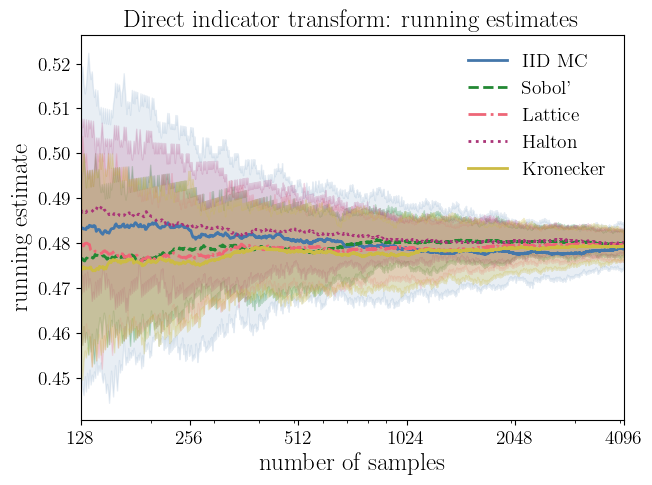

,method,Direct final_sd,Direct sd_ratio_vs_iid
0,IID MC,0.007567,1.000000
1,Sobol',0.004675,0.617849
2,Lattice,0.004843,0.640002
3,Halton,0.004324,0.571459
4,Kronecker,0.004830,0.638288


In [9]:
running, summary = run_transform_benchmark(
    transform_key,
    n=n,
    n_min_plot=n_min_plt,
)

transforms[transform_key]["summary"]

# Genz conditional transformation

The direct transformation writes the posterior Gaussian vector as

$$
\vF = \vmu + L\vZ,
\qquad
\vZ \sim \mathcal{N}(\vzero,I),
$$

and estimates

$$
p =
\Pr\{\vF \le c\mathbf{1}\mid \vy\}
=
\mathbb{E}\left[
\mathbf{1}\{\vmu + L\vZ \le c\mathbf{1}\}
\right].
$$

This gives a discontinuous indicator integrand.

The Genz transformation uses the triangular structure of $L$ to condition sequentially.  At step $j$, after choosing
$Z_1,\ldots,Z_{j-1}$, the constraint on $F_j$ becomes

$$
\mu_j + \sum_{k<j} L_{jk} Z_k + L_{jj} Z_j \le c.
$$

Equivalently,

$$
Z_j \le b_j(Z_1,\ldots,Z_{j-1})
=
\frac{
c-\mu_j-\sum_{k<j} L_{jk} Z_k
}{
L_{jj}
}.
$$

Thus the conditional probability of satisfying the $j$th constraint is

$$
\Phi\!\left(b_j(Z_1,\ldots,Z_{j-1})\right).
$$

Instead of sampling $Z_j$ from an ordinary normal distribution and then checking whether the constraint is satisfied, we sample it from the corresponding truncated normal distribution:

$$
Z_j
=
\Phi^{-1}
\left(
U_j \,
\Phi\!\left(b_j(Z_1,\ldots,Z_{j-1})\right)
\right),
\qquad
U_j \sim \mathcal{U}(0,1).
$$

The probability is then written as the smooth product integral

$$
p
=
\int_{[0,1]^d}
\prod_{j=1}^d
\Phi\!\left(b_j(Z_1,\ldots,Z_{j-1})\right)
\,\dif \vu .
$$

The event is the same, but the integrand is no longer a hard $0$-$1$ indicator.  This change of variables often makes the problem much more favorable for QMC.

In [13]:
def make_genz_upper_integrand(mu, cov, upper, jitter=1e-12):
    mu = np.asarray(mu)
    upper = np.asarray(upper)

    d = len(mu)

    L = np.linalg.cholesky(cov + jitter * np.eye(d))

    def genz_integrand(u):
        u = np.asarray(u)
        original_shape = u.shape[:-1]
        d_in = u.shape[-1]
    
        u = u.reshape(-1, d_in)
        u = np.clip(u, np.finfo(float).eps, 1 - np.finfo(float).eps)
    
        n = u.shape[0]
        z = np.zeros((n, d))
        prod = np.ones(n)
    
        for j in range(d):
            if j == 0:
                cond_mean = mu[j]
            else:
                cond_mean = mu[j] + z[:, :j] @ L[j, :j]
    
            sd = L[j, j]
            bj = (upper[j] - cond_mean) / sd
    
            Phi_bj = stats.norm.cdf(bj)
            Phi_bj = np.clip(Phi_bj, np.finfo(float).eps, 1.0)
    
            prod *= Phi_bj
            z[:, j] = stats.norm.ppf(u[:, j] * Phi_bj)
    
        return prod.reshape(original_shape)
        
    return genz_integrand
    
upper = threshold * np.ones(d_grid)

genz_integrand = make_genz_upper_integrand(
    mu=post_mean,
    cov=post_cov,
    upper=upper,
    jitter=jitter,
)

transforms["genz"] = {
    "label": "Genz conditional transform",
    "short_label": "Genz",
    "integrand": genz_integrand,
    "savefig_suffix": "genz",
}

transform_key = "genz"
transform = transforms[transform_key]

## Genz MC and Sobol check

In [19]:
check_transform_estimates(transform_key)

print(transforms[transform_key]["check"]["message"])
print("\nFor comparison, using the direct transform:\n")
print(transforms["direct"]["check"]["message"])

For the Genz conditional transform
Based on n = 4096 samples
IID MC:  0.48317 +/- 0.00734
Sobol' G:  0.47848 +/- 0.00091  (CubQMCNetG bound)
Sobol' CLT:  0.47923 +/- 0.00674  (CubQMCRepStudentT bound)

For comparison, using the direct transform:

For the Direct indicator transform
Based on n = 4096 samples
IID MC:  0.48291 +/- 0.01531
Sobol' G:  0.47998 +/- 0.00167  (CubQMCNetG bound)
Sobol' CLT:  0.46875 +/- 0.01386  (CubQMCRepStudentT bound)


### Genz Benchmarks

/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/kronecker.py:276: RuntimeWarning: CBC generating vector only supports dimension <= 13; falling back to Richtmyer.
  warnings.warn(


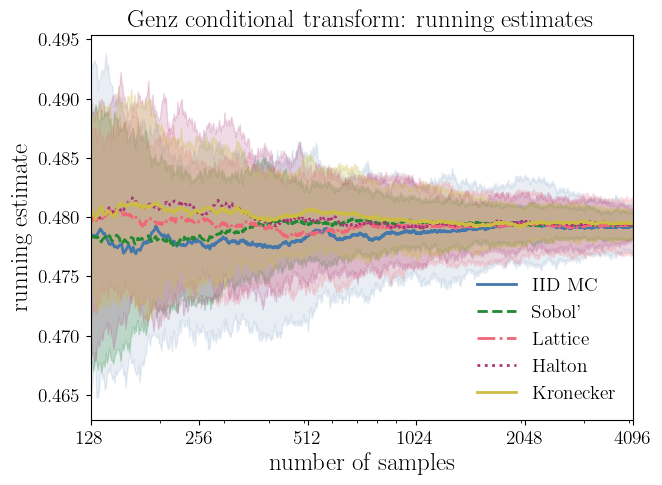

,method,Genz final_sd,Genz sd_ratio_vs_iid
0,IID MC,0.003306,1.000000
1,Sobol',0.001577,0.476982
2,Lattice,0.002904,0.878494
3,Halton,0.002369,0.716425
4,Kronecker,0.001825,0.551987


In [20]:
running, summary = run_transform_benchmark(
    transform_key,
    n=n,
    n_min_plot=n_min_plt,
)

transforms[transform_key]["summary"]

In [21]:
summary_all = transforms["direct"]["summary"].merge(
    transforms["genz"]["summary"],
    on="method",
    how="outer",
)

summary_all

,method,Direct final_sd,Direct sd_ratio_vs_iid,Genz final_sd,Genz sd_ratio_vs_iid
0,Halton,0.004324,0.571459,0.002369,0.716425
1,IID MC,0.007567,1.000000,0.003306,1.000000
2,Kronecker,0.004830,0.638288,0.001825,0.551987
3,Lattice,0.004843,0.640002,0.002904,0.878494
4,Sobol',0.004675,0.617849,0.001577,0.476982


# A smoother quantity of interest

The direct transform estimates the excursion probability

$$
p
=
\Pr\{\vf \le c\mathbf 1 \mid \vy\}
=
\mathbb{E}\left[
\mathbf 1\{\max_j f_j \le c\}
\right].
$$

This produces a discontinuous $0$-$1$ integrand.

Instead, we may estimate a smoother “safety score” that penalizes threshold exceedance continuously:

$$
g(\vf)
=
\exp\bigl(
-\lambda \max_j (f_j-c)_+
\bigr),
$$

where

$$
(x)_+ = \max(x,0).
$$

Thus

$$
g(\vf)
=
1
\qquad \text{if } f_j \le c \text{ for all } j,
$$

and the value decays smoothly as the threshold is exceeded.

The corresponding integral becomes

$$
\mathbb{E}\bigl[g(\vf)\mid \vy\bigr]
=
\int_{[0,1]^d}
g\!\left(
\vmu + L\Phi^{-1}(\vu)
\right)
\,\dif \vu .
$$

Because the integrand is now smooth rather than discontinuous, QMC methods often achieve substantially greater variance reduction.

## Smoother integrand

In [25]:
def smooth_safety_integrand(u, lam=20):
    u = np.asarray(u)
    u = np.clip(u, np.finfo(float).eps, 1 - np.finfo(float).eps)

    z = stats.norm.ppf(u)
    f_samples = post_mean + z @ L_post.T

    exceedance = np.maximum(f_samples - threshold, 0)
    max_exceedance = np.max(exceedance, axis=-1)

    return np.exp(-lam * max_exceedance)

transforms["smooth"] = {
    "label": "Smooth safety transform",
    "short_label": "Smooth",
    "integrand": smooth_safety_integrand,
    "savefig_suffix": "smooth",
}

transform_key = "smooth"

## Check

In [26]:
check_transform_estimates(transform_key)
print(transforms[transform_key]["check"]["message"])

For the Smooth safety transform
Based on n = 4096 samples
IID MC:  0.54698 +/- 0.01412
Sobol' G:  0.54918 +/- 0.00138  (CubQMCNetG bound)
Sobol' CLT:  0.54674 +/- 0.01045  (CubQMCRepStudentT bound)


/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/kronecker.py:276: RuntimeWarning: CBC generating vector only supports dimension <= 13; falling back to Richtmyer.
  warnings.warn(


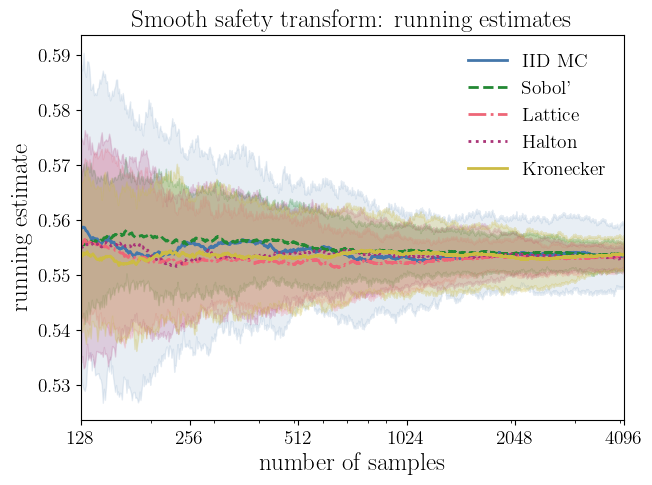

,method,Smooth final_sd,Smooth sd_ratio_vs_iid
0,IID MC,0.007925,1.000000
1,Sobol',0.004134,0.521672
2,Lattice,0.003448,0.435052
3,Halton,0.003206,0.404577
4,Kronecker,0.004334,0.546820


In [27]:
running, summary = run_transform_benchmark(
    transform_key,
    n=n,
    n_min_plot=n_min_plt,
)

transforms[transform_key]["summary"]